# Poster Visualizations
### Utah Legislature Bill Outcome Analysis — DS 2500 Final Project

This notebook generates the four visualizations for the poster:
1. Subject × Party pass rate heatmap
2. Pass rate by primary subject bar chart
3. Decision tree (human-readable)
4. Random forest feature importance

All figures are saved as high-resolution PNGs for import into Canva.

## Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Poster-friendly styling: larger fonts, NO gridlines, clean look
sns.set_style('white')  # no grid
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})

In [17]:
# Load data and prepare analysis sample
df_primary = pd.read_csv('df_primary.csv')
df_bills = pd.read_csv('df_bills.csv')[['bill_id', 'session_year', 'party', 'party1']]
df_raw = df_primary.merge(df_bills, on=['bill_id', 'session_year'], how='left')

df = df_raw[df_raw['floorspon1'] == 1].copy()
df = df.dropna(subset=['party1']).copy()
df['party1'] = df['party1'].astype(int)
df['house_origin'] = (df['originating_chamber'] == 'House').astype(int)
df['subjects_changed_bin'] = df['subjects_changed'].astype(int)

SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']

SUBJECT_LABELS = {
    'agri_food': 'Agriculture & Food',
    'arts_cult_rec': 'Arts, Culture & Rec',
    'bus_comm': 'Business & Commerce',
    'civ_rights_libs': 'Civil Rights',
    'crim_justice': 'Criminal Justice',
    'econ_dev': 'Economic Development',
    'ed_k12': 'K-12 Education',
    'elect_gov': 'Elections & Gov Ops',
    'energy': 'Energy',
    'env_nr': 'Environment & Nat. Res.',
    'fam_ss': 'Family & Social Svcs',
    'health_care': 'Healthcare',
    'higher_ed': 'Higher Education',
    'house_land_use': 'Housing & Land Use',
    'labor_ee': 'Labor & Employment',
    'local_gov': 'Local Government',
    'pub_safe_emerg': 'Public Safety',
    'retire_ben': 'Retirement & Benefits',
    'tax_fin': 'Taxes & Finance',
    'tech_data': 'Technology & Data',
    'transpo': 'Transportation'
}

COVARIATE_LABELS = {
    'committee1': 'Came from Committee',
    'money1': 'Money Appropriated',
    'num_sub_new': '# of Substitutes',
    'money_sum_real': 'Total $ Appropriated',
    'party1': 'Republican Sponsor',
    'house_origin': 'House Origin',
    'subjects_changed_bin': 'Subjects Changed',
}

print(f"Analysis sample: {len(df)} floor-sponsored bills")
print(f"Pass rate: {df['passed'].mean():.1%}")

Analysis sample: 6730 floor-sponsored bills
Pass rate: 79.5%


## Visualization 1 — Subject × Party Heatmap

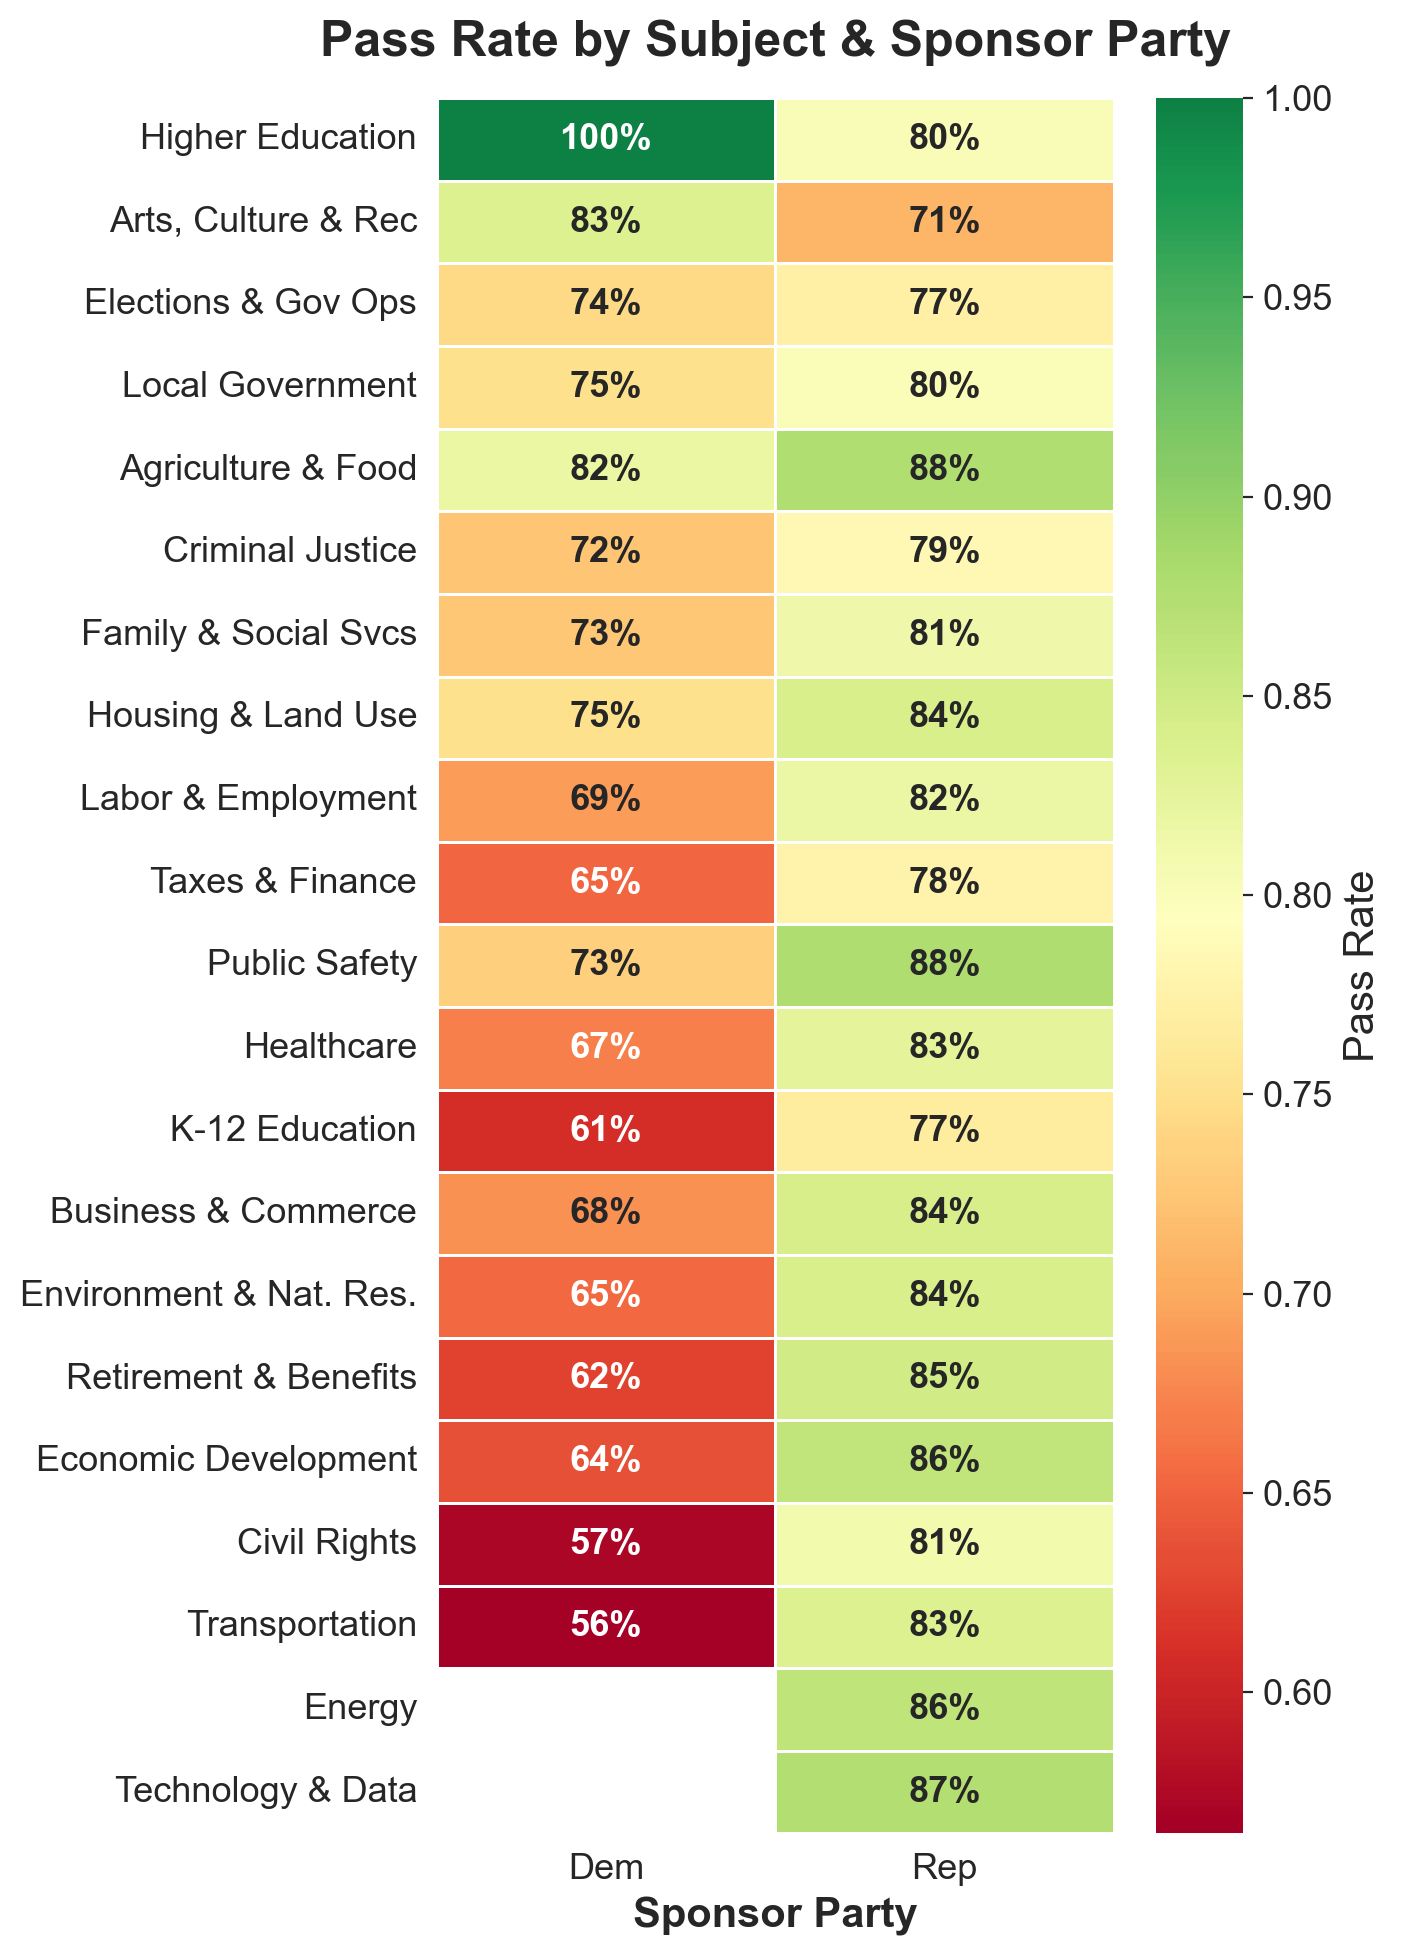

Saved: poster_01_subject_party_heatmap.png


In [18]:
subject_party = []
for col in SUBJECT_COLS:
    for party in ['Rep', 'Dem']:
        subset = df[(df[col] == 1) & (df['party'] == party)]
        if len(subset) > 5:
            subject_party.append({'subject': SUBJECT_LABELS[col], 'party': party,
                                  'pass_rate': subset['passed'].mean(), 'n': len(subset)})

sp_df = pd.DataFrame(subject_party)
sp_pivot = sp_df.pivot(index='subject', columns='party', values='pass_rate')
sp_pivot['gap'] = sp_pivot['Rep'] - sp_pivot['Dem']
sp_pivot = sp_pivot.sort_values('gap')

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(sp_pivot[['Dem', 'Rep']], annot=True, fmt='.0%', cmap='RdYlGn',
            center=df['passed'].mean(), linewidths=1, linecolor='white',
            cbar_kws={'label': 'Pass Rate'},
            annot_kws={'size': 13, 'weight': 'bold'}, ax=ax)
ax.set_title('Pass Rate by Subject & Sponsor Party', pad=15, fontweight='bold')
ax.set_xlabel('Sponsor Party', fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('poster_01_subject_party_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: poster_01_subject_party_heatmap.png")

## Visualization 2 — Pass Rate by Primary Subject

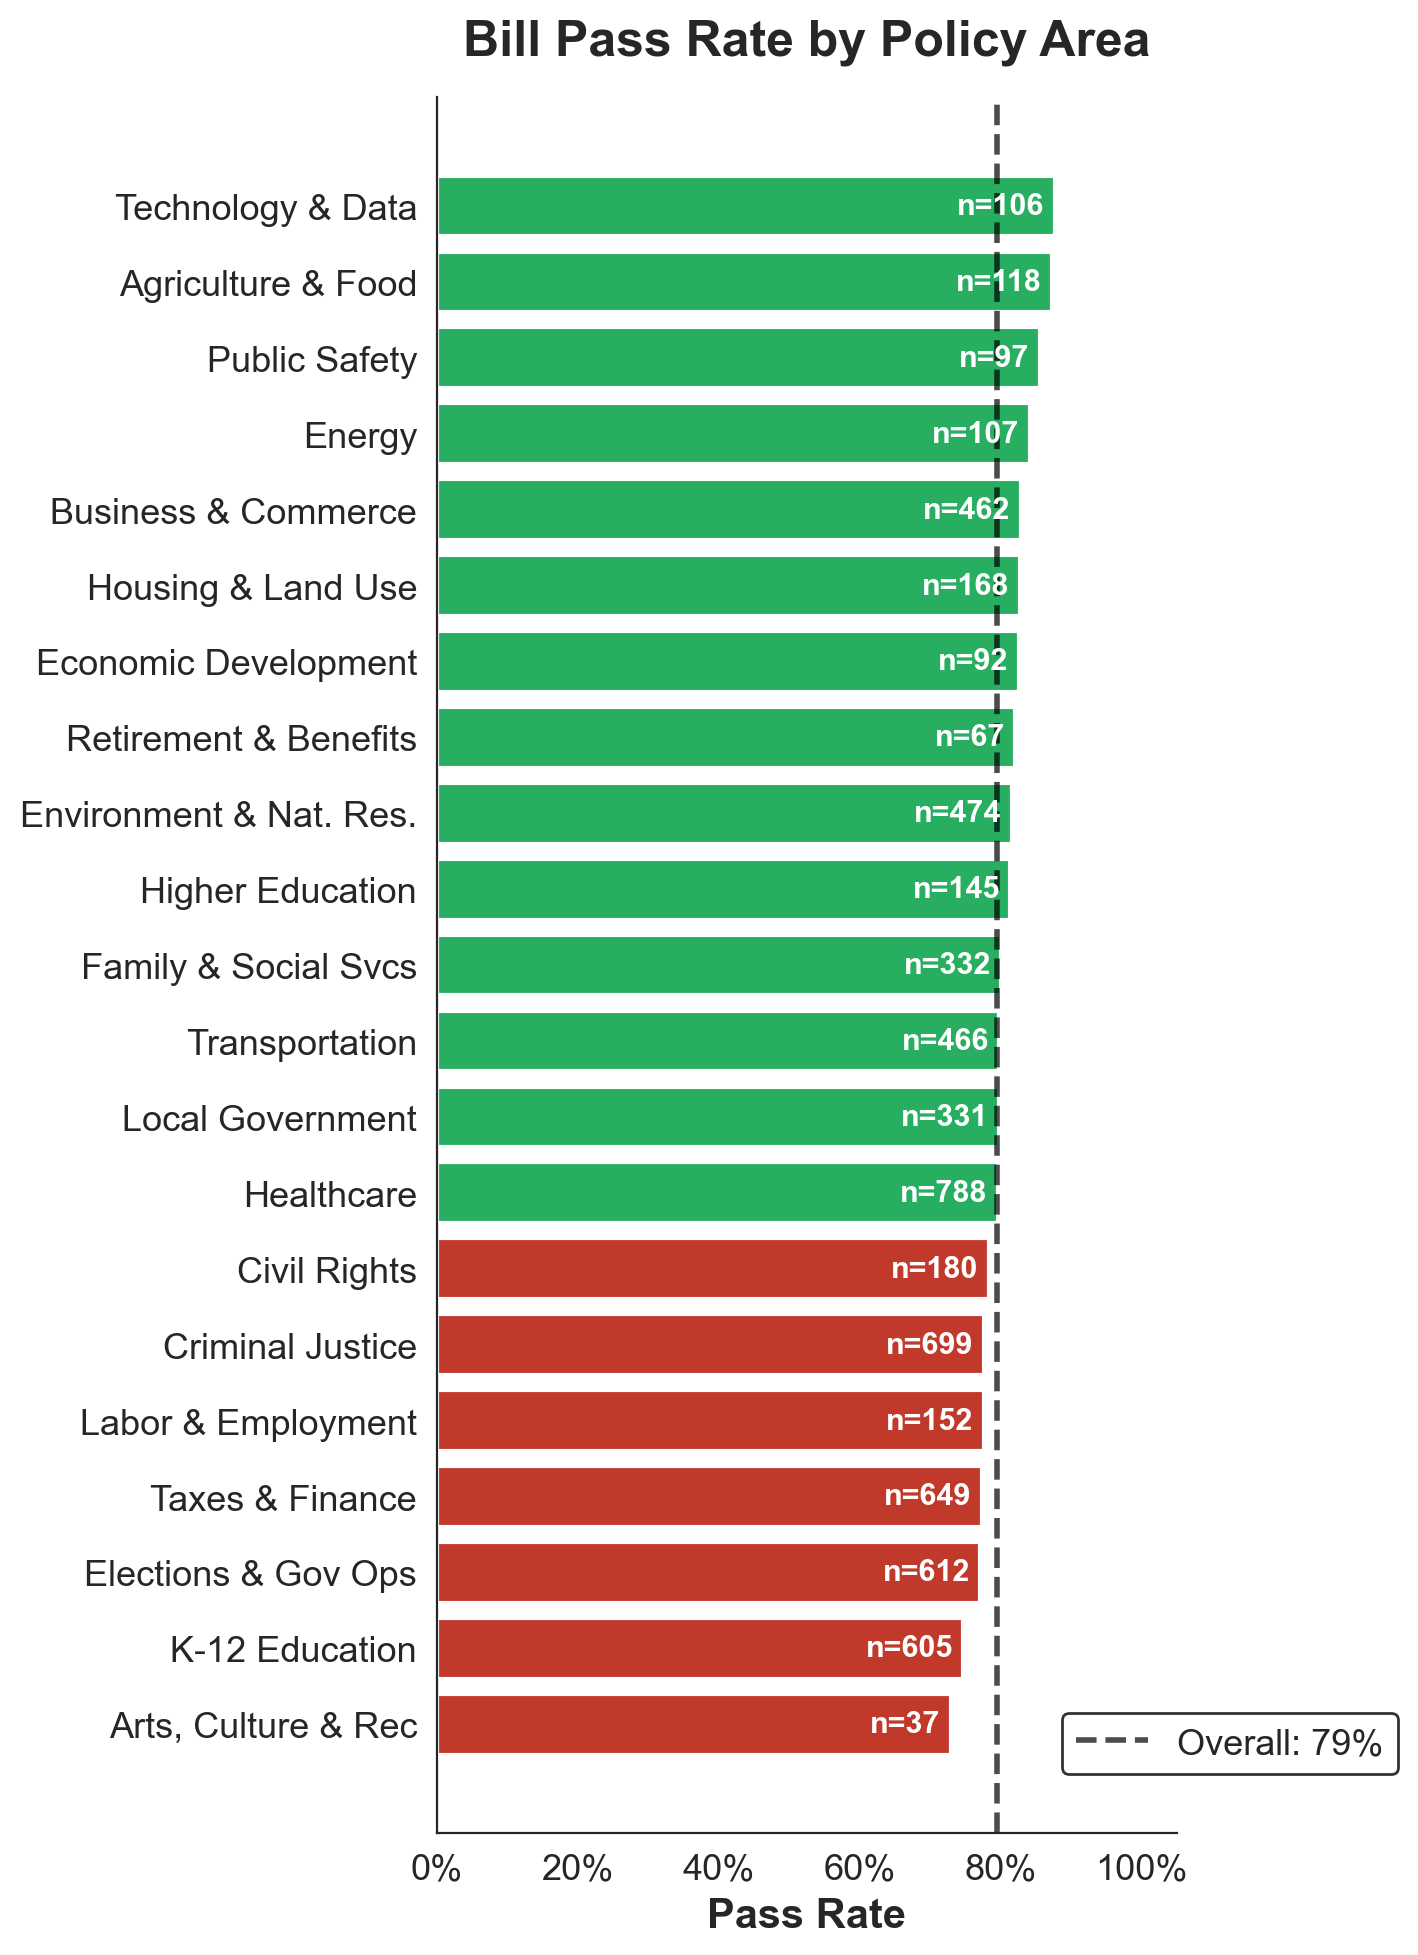

Saved: poster_02_pass_rate_by_subject.png


In [19]:
pass_rates = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        pass_rates[SUBJECT_LABELS[col]] = {
            'pass_rate': subset['passed'].mean(),
            'count': len(subset)
        }

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)
overall = df['passed'].mean()

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['#27ae60' if r > overall else '#c0392b' for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors,
               edgecolor='white', linewidth=1.5)

ax.axvline(overall, color='black', linestyle='--', linewidth=2,
           label=f'Overall: {overall:.0%}', alpha=0.7)
ax.set_xlabel('Pass Rate', fontweight='bold')
ax.set_title('Bill Pass Rate by Policy Area', pad=15, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(0.82, 0.08),
          frameon=True, edgecolor='black')
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() - 0.015, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', ha='right',
            fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('poster_02_pass_rate_by_subject.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: poster_02_pass_rate_by_subject.png")

## Visualization 3 — Decision Tree (Human-Readable)

Rather than using sklearn's default tree plot (which shows `feature ≤ 0.5`, gini values, and cramped sample counts), this version renders the tree manually with plain-English question labels at each decision point and clean Pass/Fail labels at leaves.

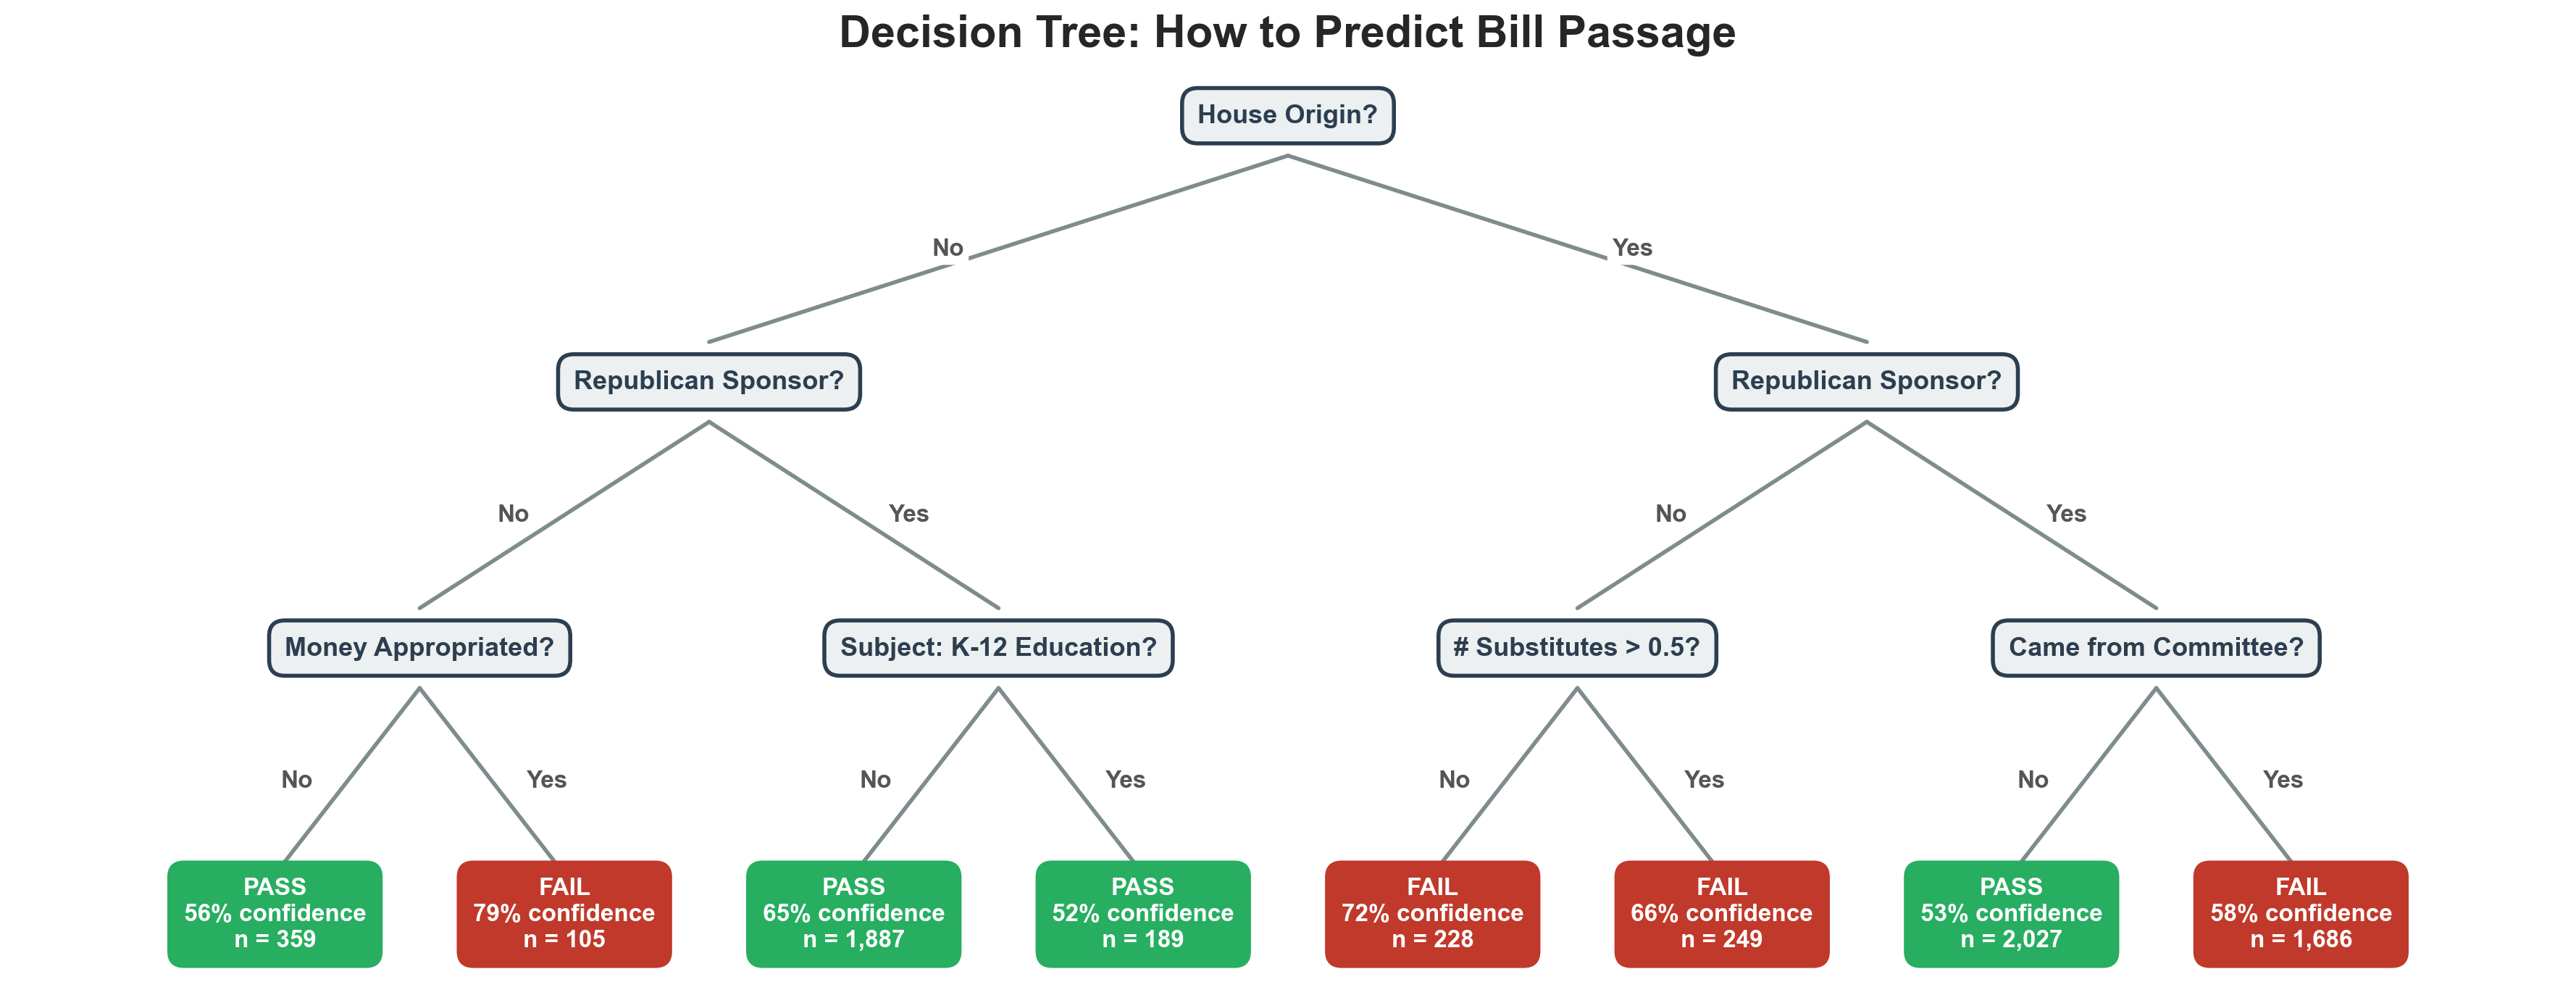

Saved: poster_03_decision_tree.png


In [20]:
feature_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']
y_full = df['passed']

dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100,
                             random_state=42, class_weight='balanced')
dt.fit(df[feature_cols], y_full)

# Extract tree structure
tree = dt.tree_
n_nodes = tree.node_count
children_left = tree.children_left
children_right = tree.children_right
feature = tree.feature
threshold = tree.threshold
value = tree.value  # [n_nodes, 1, 2] — weighted class counts

# Build human-readable split labels
def split_question(feat_idx, thresh):
    fname = feature_cols[feat_idx]
    # For binary features (threshold ~0.5), use yes/no framing
    if fname in SUBJECT_COLS:
        return f"Subject: {SUBJECT_LABELS[fname]}?"
    if fname == 'committee1':
        return "Came from Committee?"
    if fname == 'money1':
        return "Money Appropriated?"
    if fname == 'party1':
        return "Republican Sponsor?"
    if fname == 'house_origin':
        return "House Origin?"
    if fname == 'subjects_changed_bin':
        return "Subjects Changed?"
    # Continuous features
    if fname == 'num_sub_new':
        return f"# Substitutes > {thresh:.1f}?"
    if fname == 'money_sum_real':
        return "Money Appropriated?"
    return f"{fname} > {thresh:.2f}?"

def leaf_label(node_id):
    v = value[node_id][0]  # [failed_weight, passed_weight]
    total = v.sum()
    pct_pass = v[1] / total
    prediction = "PASS" if pct_pass > 0.5 else "FAIL"
    confidence = max(pct_pass, 1 - pct_pass)
    # Get sample count (unweighted)
    n_samples = tree.n_node_samples[node_id]
    return prediction, confidence, n_samples

# Compute positions for each node using a layout algorithm
def compute_positions(node_id=0, depth=0, x_min=0, x_max=1, positions=None):
    if positions is None:
        positions = {}
    x_center = (x_min + x_max) / 2
    positions[node_id] = (x_center, -depth)
    left = children_left[node_id]
    right = children_right[node_id]
    if left != -1:
        compute_positions(left, depth + 1, x_min, x_center, positions)
    if right != -1:
        compute_positions(right, depth + 1, x_center, x_max, positions)
    return positions

positions = compute_positions()

# Render the tree
fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-3.2, 0.2)
ax.axis('off')

PASS_COLOR = '#27ae60'
FAIL_COLOR = '#c0392b'
SPLIT_COLOR = '#ecf0f1'
SPLIT_EDGE = '#2c3e50'

# Draw edges first (so nodes appear on top)
for node_id in range(n_nodes):
    x, y = positions[node_id]
    left = children_left[node_id]
    right = children_right[node_id]
    if left != -1:
        xl, yl = positions[left]
        ax.plot([x, xl], [y - 0.15, yl + 0.15], color='#7f8c8d', linewidth=2, zorder=1)
        # Label the edge
        mx, my = (x + xl) / 2, (y + yl) / 2
        ax.text(mx - 0.015, my, 'No', fontsize=12, color='#555',
                ha='right', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))
    if right != -1:
        xr, yr = positions[right]
        ax.plot([x, xr], [y - 0.15, yr + 0.15], color='#7f8c8d', linewidth=2, zorder=1)
        mx, my = (x + xr) / 2, (y + yr) / 2
        ax.text(mx + 0.015, my, 'Yes', fontsize=12, color='#555',
                ha='left', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))

# Draw nodes
for node_id in range(n_nodes):
    x, y = positions[node_id]
    is_leaf = children_left[node_id] == -1

    if is_leaf:
        pred, conf, n = leaf_label(node_id)
        color = PASS_COLOR if pred == 'PASS' else FAIL_COLOR
        box_text = f'{pred}\n{conf:.0%} confidence\nn = {n:,}'
        ax.text(x, y, box_text, ha='center', va='center', fontsize=12,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.6', facecolor=color,
                          edgecolor=color, linewidth=2), zorder=3)
    else:
        question = split_question(feature[node_id], threshold[node_id])
        ax.text(x, y, question, ha='center', va='center', fontsize=13,
                fontweight='bold', color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.6', facecolor=SPLIT_COLOR,
                          edgecolor=SPLIT_EDGE, linewidth=2), zorder=3)

ax.set_title('Decision Tree: How to Predict Bill Passage',
             fontsize=22, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('poster_03_decision_tree.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: poster_03_decision_tree.png")

## Visualization 4 — Random Forest Feature Importance (Top 10)

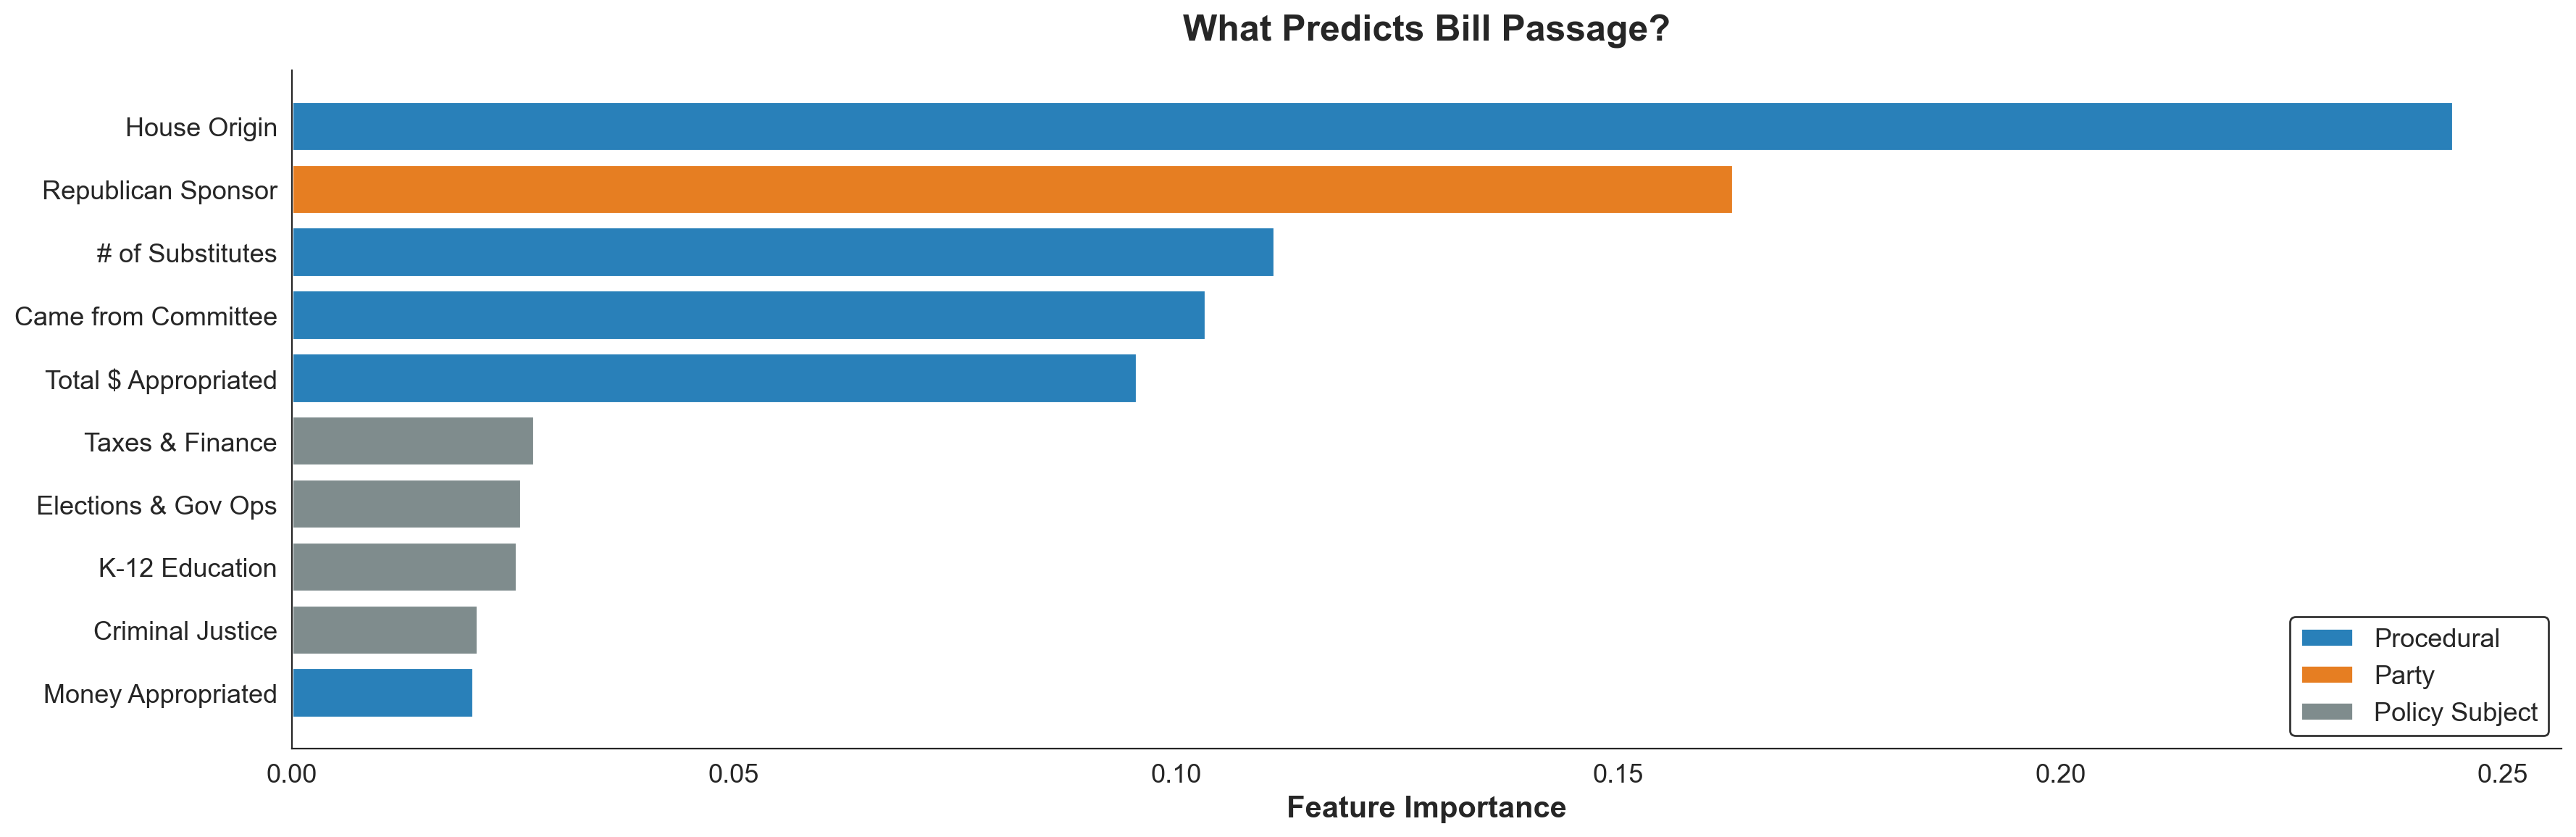

Saved: poster_04_rf_importance.png


In [22]:
# Rebuild readable feature names list in the same order as feature_cols
readable_names = []
for f in feature_cols:
    if f in SUBJECT_LABELS:
        readable_names.append(SUBJECT_LABELS[f])
    elif f in COVARIATE_LABELS:
        readable_names.append(COVARIATE_LABELS[f])
    else:
        readable_names.append(f)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(df[feature_cols], y_full)

imp_df = pd.DataFrame({
    'Feature': readable_names,
    'Importance': rf.feature_importances_,
    'raw': feature_cols
}).sort_values('Importance', ascending=True)

# Keep only the top 10 most important features — the story is clearest
# with procedural variables + party + a handful of top policy areas.
imp_df = imp_df.tail(10)

procedural = ['committee1', 'money1', 'num_sub_new', 'money_sum_real',
              'house_origin', 'subjects_changed_bin']
party_vars = ['party1']

colors = []
for raw in imp_df['raw']:
    if raw in party_vars:
        colors.append('#e67e22')
    elif raw in procedural:
        colors.append('#2980b9')
    else:
        colors.append('#7f8c8d')

fig, ax = plt.subplots(figsize=(18, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors,
        edgecolor='white', linewidth=1.5)
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('What Predicts Bill Passage?', pad=15, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', label='Procedural'),
    Patch(facecolor='#e67e22', label='Party'),
    Patch(facecolor='#7f8c8d', label='Policy Subject'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('poster_04_rf_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: poster_04_rf_importance.png")

## Files generated

All images saved at 300 DPI, ready to drop into Canva:

- `poster_01_subject_party_heatmap.png`
- `poster_02_pass_rate_by_subject.png`
- `poster_03_decision_tree.png`
- `poster_04_rf_importance.png`